# 5.1 Feature ablation



## Method funcs (aka final_baselines)

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from numpy.linalg import pinv
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)
DATA="/data/"
SEEDS=(42,1,2,3,4); RS=42; FPR_GRID=(0.05,0.10,0.20)
UAV_CFG={"path":DATA+"UAVIDS-2025.csv","label_col":"label","normal":"Normal Traffic",
  "attacks":["Blackhole Attack","Flooding Attack","Sybil Attack","Wormhole Attack"],
  "leak_clean":["FlowID","SrcAddr","DstAddr","Protocol"]}
ID_CFG={"src":"SrcAddr","dst":"DstAddr"}; TARGET="Sybil Attack"
RATE=["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]
print("config ok")

config ok


In [ ]:
def load(cfg): return pd.read_csv(cfg["path"],low_memory=False).reset_index(drop=True)
def source_rate_features(df,idcfg):
    src=idcfg["src"]; dst=idcfg["dst"]
    s=df[src].astype(str).fillna("NA").values; dd=df[dst].astype(str).fillna("NA").values
    tmp=pd.DataFrame({"s":s,"d":dd}); g=tmp.groupby("s")
    flowcount=g["s"].transform("size").astype(float).values; fanout=g["d"].transform("nunique").astype(float).values
    ent_map={}
    for k,gg in tmp.groupby("s"):
        vc=gg["d"].value_counts().values.astype(float); p=vc/vc.sum(); ent_map[k]=float(-(p*np.log(p+1e-12)).sum())
    ent=np.array([ent_map[x] for x in s]); fc=np.clip(flowcount,1,None); fo=np.clip(fanout,1,None)
    return pd.DataFrame({"s_fanout_rate":fanout/fc,"s_flows_per_dst":flowcount/fo,
                         "s_dst_entropy_norm":ent/np.log(np.clip(fanout,2,None))}).fillna(0.0).reset_index(drop=True)
def feats_perflow(df,cfg):
    # CLEAN per-flow: drop leak_clean, label, AND any source-rate columns
    drop=set(cfg["leak_clean"])|{cfg["label_col"]}|set(RATE)
    X=df.drop(columns=[c for c in df.columns if c in drop],errors="ignore").copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]): X[c]=LabelEncoder().fit_transform(X[c].astype(str))
    return X.astype(float).reset_index(drop=True)
def loaco_split(df,label_col,target,seed,val=0.3,test=0.3):
    rng=np.random.default_rng(seed)
    dft=df[df[label_col].astype(str)==target]; dfk=df[df[label_col].astype(str)!=target]
    idx=rng.permutation(len(dfk)); nv=int(len(idx)*val)
    valk=dfk.iloc[idx[:nv]]; tr=dfk.iloc[idx[nv:]]; nt=int(len(tr)*test)
    return tr.iloc[nt:], valk, pd.concat([tr.iloc[:nt],dft])
def ae_(n,seed):
    b=max(2,n//4)
    return MLPRegressor(hidden_layer_sizes=(max(8,n//2),b,max(8,n//2)),max_iter=150,early_stopping=True,n_iter_no_change=8,random_state=seed)
def ae_err(ae,X):
    r=ae.predict(X); r=r.reshape(-1,1) if r.ndim==1 else r; return np.mean((X-r)**2,1)
def fit_mahal(Xn):
    mu=Xn.mean(0); cov=np.cov(Xn.T)+1e-6*np.eye(Xn.shape[1]); return mu,pinv(cov)
def mahal(X,mu,P):
    d=X-mu; return np.einsum('ij,jk,ik->i',d,P,d)
def Z(A,Bv,Be):
    imp=SimpleImputer(strategy="mean").fit(A); sca=StandardScaler().fit(imp.transform(A))
    return sca.transform(imp.transform(A)),sca.transform(imp.transform(Bv)),sca.transform(imp.transform(Be))
print("helpers ok")

helpers ok


In [ ]:
def _Z(A, Be):               # impute+scale on A (train), apply to Be (test)
    imp=SimpleImputer(strategy="mean").fit(A); sc=StandardScaler().fit(imp.transform(A))
    return sc.transform(imp.transform(A)), sc.transform(imp.transform(Be))

## Ablation funcs

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

RATE = ["s_fanout_rate","s_flows_per_dst","s_dst_entropy_norm"]  # fan-out, concentration, entropy

def _prep(seed):
    """LOACO source-disjoint split + source-rate özellikleri hazırla."""
    cfg=UAV_CFG; lab=cfg["label_col"]; normal=cfg["normal"]; tgt=TARGET; src=ID_CFG["src"]
    df=load(cfg); df=pd.concat([df, source_rate_features(df,ID_CFG)],axis=1)
    tr,valk,test_=loaco_split(df,lab,tgt,seed); test_=test_.reset_index(drop=True)
    ytr=tr[lab].astype(str).values; ye=test_[lab].astype(str).values
    is_t=(ye==tgt); bmask=(ytr==normal)
    seen=is_t & test_[src].astype(str).isin(set(tr[src].astype(str))).values; sdj=~seen
    return tr,test_,is_t,bmask,sdj,ye,normal

In [ ]:
# ---------- (1) LEAVE-ONE-FEATURE-OUT (LOFO) ----------
# Her özelliği sırayla çıkar, kalan ikiyle benign-Mahalanobis ROC.
def lofo(seeds=SEEDS):
    subsets = {"all (3 feat)": RATE}
    for f in RATE: subsets[f"drop {f}"] = [c for c in RATE if c!=f]
    res={k:[] for k in subsets}
    for seed in seeds:
        tr,test_,is_t,bmask,sdj,_,_=_prep(seed)
        for name,feats in subsets.items():
            A=tr[feats].reset_index(drop=True); B=test_[feats].reset_index(drop=True)
            Za,Ze=_Z(A,B); mu,P=fit_mahal(Za[bmask]); s=mahal(Ze,mu,P)
            res[name].append(roc_auc_score(is_t[sdj].astype(int), s[sdj]))
    print("=== Leave-one-feature-out (benign-Mahalanobis, source-disjoint ROC) ===")
    for k,v in res.items(): print(f"  {k:22s} {np.mean(v):.3f} ± {np.std(v):.3f}")
    return res
lofo()

=== Leave-one-feature-out (benign-Mahalanobis, source-disjoint ROC) ===
  all (3 feat)           0.907 ± 0.002
  drop s_fanout_rate     0.961 ± 0.002
  drop s_flows_per_dst   0.856 ± 0.002
  drop s_dst_entropy_norm 0.608 ± 0.003


{'all (3 feat)': [np.float64(0.9052932189749289),
  np.float64(0.9054166614200893),
  np.float64(0.9048476714338611),
  np.float64(0.9105501789370423),
  np.float64(0.9088436755216953)],
 'drop s_fanout_rate': [np.float64(0.9608981718523166),
  np.float64(0.9596169458338298),
  np.float64(0.9580474013626155),
  np.float64(0.9626704793968073),
  np.float64(0.9620113898700452)],
 'drop s_flows_per_dst': [np.float64(0.8564853601987524),
  np.float64(0.8543664090632022),
  np.float64(0.8517530147719266),
  np.float64(0.8587156100505733),
  np.float64(0.8568048801540027)],
 'drop s_dst_entropy_norm': [np.float64(0.6039874255721325),
  np.float64(0.6118066929094029),
  np.float64(0.6061392638692821),
  np.float64(0.6110066654497358),
  np.float64(0.6079252112777538)]}

In [ ]:
# ---------- (2) SINGLE-FEATURE ROC ----------
# Her özellik TEK BAŞINA benign-Mahalanobis (1D).
def single_feature(seeds=SEEDS):
    res={f:[] for f in RATE}
    for seed in seeds:
        tr,test_,is_t,bmask,sdj,_,_=_prep(seed)
        for f in RATE:
            A=tr[[f]].reset_index(drop=True); B=test_[[f]].reset_index(drop=True)
            Za,Ze=_Z(A,B); mu,P=fit_mahal(Za[bmask]); s=mahal(Ze,mu,P)
            res[f].append(roc_auc_score(is_t[sdj].astype(int), s[sdj]))
    print("=== Single-feature benign-Mahalanobis (source-disjoint ROC) ===")
    for f in RATE: print(f"  {f:22s} {np.mean(res[f]):.3f} ± {np.std(res[f]):.3f}")
    return res
single_feature()

=== Single-feature benign-Mahalanobis (source-disjoint ROC) ===
  s_fanout_rate          0.579 ± 0.004
  s_flows_per_dst        0.673 ± 0.003
  s_dst_entropy_norm     0.643 ± 0.009


{'s_fanout_rate': [np.float64(0.5728193882093335),
  np.float64(0.5821188194672087),
  np.float64(0.5761430629227402),
  np.float64(0.5854730317507569),
  np.float64(0.5807325832575069)],
 's_flows_per_dst': [np.float64(0.67119266509325),
  np.float64(0.6788141011852891),
  np.float64(0.6706501516386634),
  np.float64(0.6724260431500869),
  np.float64(0.6701246046922922)],
 's_dst_entropy_norm': [np.float64(0.6468173957452902),
  np.float64(0.6342616507445533),
  np.float64(0.6299263941275635),
  np.float64(0.6520842896835175),
  np.float64(0.6500235459154875)]}

In [ ]:
# ---------- (3) RECIPROCAL TESTİ (R2.2 doğrudan) ----------
# fan-out = |D|/|F|, concentration = |F|/|D| reciprocal.
# Üç varyant: sadece fan-out+entropy / sadece concentration+entropy / üçü.
def reciprocal_test(seeds=SEEDS):
    variants = {
        "fan-out + entropy":        ["s_fanout_rate","s_dst_entropy_norm"],
        "concentration + entropy":  ["s_flows_per_dst","s_dst_entropy_norm"],
        "both + entropy (full)":    RATE,
        "fan-out + concentration (no entropy)": ["s_fanout_rate","s_flows_per_dst"],
    }
    res={k:[] for k in variants}
    for seed in seeds:
        tr,test_,is_t,bmask,sdj,_,_=_prep(seed)
        for name,feats in variants.items():
            A=tr[feats].reset_index(drop=True); B=test_[feats].reset_index(drop=True)
            Za,Ze=_Z(A,B); mu,P=fit_mahal(Za[bmask]); s=mahal(Ze,mu,P)
            res[name].append(roc_auc_score(is_t[sdj].astype(int), s[sdj]))
    print("=== Reciprocal test (fan-out vs concentration; benign-Mahalanobis) ===")
    for k,v in res.items(): print(f"  {k:38s} {np.mean(v):.3f} ± {np.std(v):.3f}")
    print(">>> R2.2: fan-out ve concentration reciprocal olsa da,")
    print(">>> ikisini birlikte tutmak marjinal kazanç veriyor mu? (full vs tek-taraf)")
    return res
reciprocal_test()

=== Reciprocal test (fan-out vs concentration; benign-Mahalanobis) ===
  fan-out + entropy                      0.856 ± 0.002
  concentration + entropy                0.961 ± 0.002
  both + entropy (full)                  0.907 ± 0.002
  fan-out + concentration (no entropy)   0.608 ± 0.003
>>> R2.2: fan-out ve concentration reciprocal olsa da,
>>> ikisini birlikte tutmak marjinal kazanç veriyor mu? (full vs tek-taraf)


{'fan-out + entropy': [np.float64(0.8564853601987524),
  np.float64(0.8543664090632022),
  np.float64(0.8517530147719266),
  np.float64(0.8587156100505733),
  np.float64(0.8568048801540027)],
 'concentration + entropy': [np.float64(0.9608981718523166),
  np.float64(0.9596169458338298),
  np.float64(0.9580474013626155),
  np.float64(0.9626704793968073),
  np.float64(0.9620113898700452)],
 'both + entropy (full)': [np.float64(0.9052932189749289),
  np.float64(0.9054166614200893),
  np.float64(0.9048476714338611),
  np.float64(0.9105501789370423),
  np.float64(0.9088436755216953)],
 'fan-out + concentration (no entropy)': [np.float64(0.6039874255721325),
  np.float64(0.6118066929094029),
  np.float64(0.6061392638692821),
  np.float64(0.6110066654497358),
  np.float64(0.6079252112777538)]}

In [ ]:
# ---------- (4) PERMÜTASYON-ÖNEM ----------
# Her özelliği test'te permüte et, ROC düşüşü = önem.
def perm_importance(seeds=SEEDS):
    res={f:[] for f in RATE}; base=[]
    for seed in seeds:
        tr,test_,is_t,bmask,sdj,_,_=_prep(seed)
        A=tr[RATE].reset_index(drop=True); B=test_[RATE].reset_index(drop=True)
        Za,Ze=_Z(A,B); mu,P=fit_mahal(Za[bmask])
        s0=mahal(Ze,mu,P); auc0=roc_auc_score(is_t[sdj].astype(int), s0[sdj]); base.append(auc0)
        rng=np.random.default_rng(seed)
        for j,f in enumerate(RATE):
            Zp=Ze.copy(); Zp[:,j]=rng.permutation(Zp[:,j])
            sp=mahal(Zp,mu,P); aucp=roc_auc_score(is_t[sdj].astype(int), sp[sdj])
            res[f].append(auc0-aucp)   # ROC düşüşü
    print(f"=== Permutation importance (ROC drop; base={np.mean(base):.3f}) ===")
    for f in RATE: print(f"  {f:22s} Δ={np.mean(res[f]):+.3f} ± {np.std(res[f]):.3f}")
    return res
perm_importance()

=== Permutation importance (ROC drop; base=0.907) ===
  s_fanout_rate          Δ=+0.114 ± 0.004
  s_flows_per_dst        Δ=+0.212 ± 0.004
  s_dst_entropy_norm     Δ=+0.325 ± 0.003


{'s_fanout_rate': [np.float64(0.11131867060706269),
  np.float64(0.11742286315442663),
  np.float64(0.11968261510210687),
  np.float64(0.1110194800983868),
  np.float64(0.11143872458145554)],
 's_flows_per_dst': [np.float64(0.21351290516924404),
  np.float64(0.2154158912449715),
  np.float64(0.21695822909768858),
  np.float64(0.20532613649786868),
  np.float64(0.20824383690435022)],
 's_dst_entropy_norm': [np.float64(0.3196615087681399),
  np.float64(0.3235911046646963),
  np.float64(0.3257268389792187),
  np.float64(0.33002192596877833),
  np.float64(0.324002491591054)]}

## Plot

=== Permutation importance (ROC drop; base=0.907) ===
  s_fanout_rate          Δ=+0.114 ± 0.004
  s_flows_per_dst        Δ=+0.212 ± 0.004
  s_dst_entropy_norm     Δ=+0.325 ± 0.003


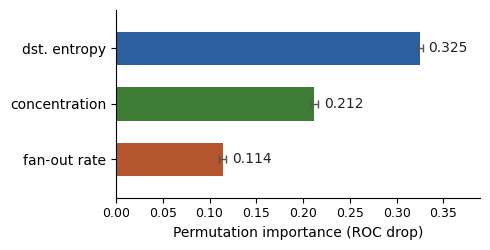

kaydedildi: fig_permimp.pdf fig_permimp.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === AYARLAR (serbestçe değiştir) ===
FIGSIZE   = (5.0, 2.6)      # inç (tek-kolon dostu)
FONT      = "DejaVu Sans"   # font ailesi
FS_LABEL  = 10              # eksen/etiket font
FS_VALUE  = 10              # bar ucundaki sayı font
FS_XLABEL = 10
COLORS    = {"s_dst_entropy_norm":"#2c5f9e",   # entropy - mavi
             "s_flows_per_dst":   "#3e7d35",   # concentration - yeşil
             "s_fanout_rate":     "#b5562e"}   # fan-out - kırmızı
LABELS    = {"s_dst_entropy_norm":"dst. entropy",
             "s_flows_per_dst":   "concentration",
             "s_fanout_rate":     "fan-out rate"}
OUT_PDF   = "fig_permimp.pdf"
OUT_PNG   = "fig_permimp.png"

plt.rcParams["font.family"] = FONT

# perm_importance() çıktısını kullan: her feature için ROC-drop ortalaması
imp = perm_importance()                      # {feat: [seed drops]}
order = ["s_dst_entropy_norm","s_flows_per_dst","s_fanout_rate"]  # büyükten küçüğe
means = [np.mean(imp[f]) for f in order]
stds  = [np.std(imp[f])  for f in order]
ylabels = [LABELS[f] for f in order]
colors  = [COLORS[f] for f in order]

fig, ax = plt.subplots(figsize=FIGSIZE)
y = np.arange(len(order))[::-1]              # entropy en üstte
bars = ax.barh(y, means, xerr=stds, color=colors, height=0.6,
               error_kw=dict(ecolor="#555", capsize=3, lw=1))

# bar ucuna değer yaz
for yi, m, s in zip(y, means, stds):
    ax.text(m + s + 0.006, yi, f"{m:.3f}", va="center",
            fontsize=FS_VALUE, color="#222")

ax.set_yticks(y)
ax.set_yticklabels(ylabels, fontsize=FS_LABEL)
ax.set_xlabel("Permutation importance (ROC drop)", fontsize=FS_XLABEL)
ax.set_xlim(0, max(means) + max(stds) + 0.06)
ax.tick_params(axis="x", labelsize=FS_LABEL-1)
ax.spines[["top","right"]].set_visible(False)
ax.margins(y=0.15)

plt.tight_layout()
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
print("kaydedildi:", OUT_PDF, OUT_PNG)